In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Paths
# =========================================================
results_directory = r"..\project_1_output\combined_horizon_models_2022_2025"
figures_directory = os.path.join(results_directory, "figures")
os.makedirs(figures_directory, exist_ok=True)

overall_results_path = os.path.join(results_directory, "overall_horizon_model_results.csv")
paper_summary_table_path = os.path.join(results_directory, "paper_summary_table.csv")
per_year_results_path = os.path.join(results_directory, "per_year_horizon_model_results.csv")
per_tmc_results_path = os.path.join(results_directory, "per_tmc_horizon_model_results.csv")

overall_results = pd.read_csv(overall_results_path)
paper_summary_table = pd.read_csv(paper_summary_table_path)
per_year_results = pd.read_csv(per_year_results_path)
per_tmc_results = pd.read_csv(per_tmc_results_path)

# =========================================================
# Standardize model names
# =========================================================
model_name_map = {
    "Persistence": "Persistence",
    "LinearRegression": "Linear Regression",
    "RandomForest": "Random Forest",
    "XGBoost": "XGBoost",
    "Linear Regression": "Linear Regression",
    "Random Forest": "Random Forest",
}

for df in [overall_results, paper_summary_table, per_year_results, per_tmc_results]:
    df["model"] = df["model"].replace(model_name_map)

# =========================================================
# Ordering and style
# =========================================================
horizon_order = ["5min", "15min", "30min"]
model_order = ["Persistence", "Linear Regression", "Random Forest", "XGBoost"]

marker_map = {
    "Persistence": "o",
    "Linear Regression": "s",
    "Random Forest": "^",
    "XGBoost": "D",
}

for df in [overall_results, paper_summary_table, per_year_results, per_tmc_results]:
    df["horizon"] = pd.Categorical(df["horizon"], categories=horizon_order, ordered=True)
    df["model"] = pd.Categorical(df["model"], categories=model_order, ordered=True)

In [2]:
# Helper for line plots
# ------------------------------------------------------------------
def save_overall_metric_plot(plot_df, metric_column, y_label, title, output_name):
    plot_data = (
        plot_df
        .pivot(index="horizon", columns="model", values=metric_column)
        .reindex(horizon_order)
    )

    plt.figure(figsize=(8, 5))

    for current_model in model_order:
        if current_model in plot_data.columns:
            plt.plot(
                plot_data.index.astype(str),
                plot_data[current_model],
                marker=marker_map[current_model],
                linewidth=2,
                markersize=7,
                label=current_model
            )

    plt.xlabel("Forecast Horizon")
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(os.path.join(figures_directory, output_name), dpi=300, bbox_inches="tight")
    plt.show()

### Figure. MAE vs horizon by model

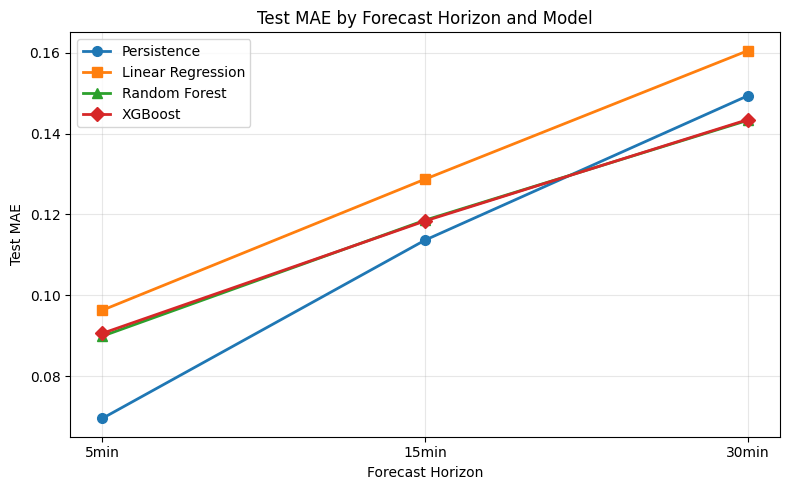

In [3]:
# Figure 1. MAE by horizon (test MAE)
# ------------------------------------------------------------------
save_overall_metric_plot(
    overall_results,
    metric_column="test_mae",
    y_label="Test MAE",
    title="Test MAE by Forecast Horizon and Model",
    output_name="figure_01_test_mae_by_horizon_model.png"
)


#### Figure. RMSE vs horizon by model

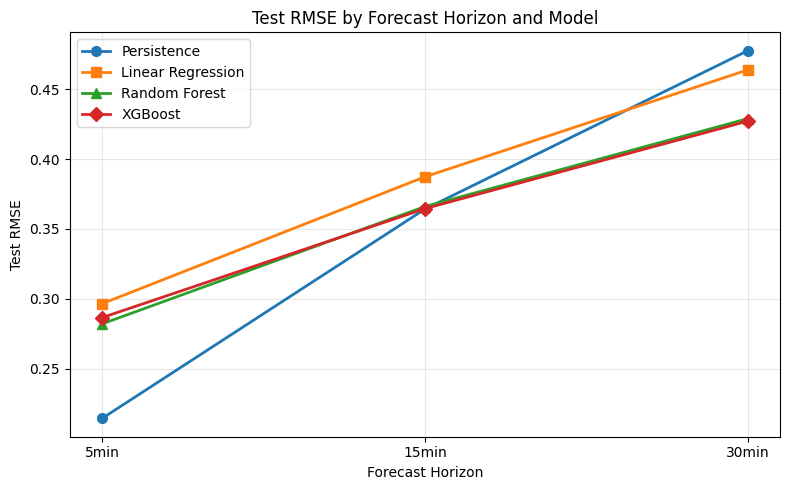

In [4]:
# Figure 2. RMSE by horizon(test RMSE)
# ------------------------------------------------------------------
save_overall_metric_plot(
    overall_results,
    metric_column="test_rmse",
    y_label="Test RMSE",
    title="Test RMSE by Forecast Horizon and Model",
    output_name="figure_02_test_rmse_by_horizon_model.png"
)

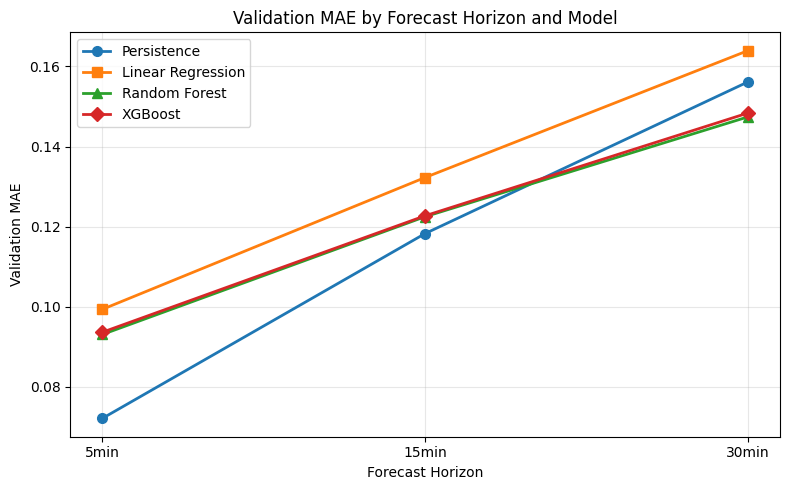

In [5]:
# Figure 3. Validation MAE by horizon
# Optional but useful for appendix/check
# =========================================================
save_overall_metric_plot(
    overall_results,
    metric_column="validation_mae",
    y_label="Validation MAE",
    title="Validation MAE by Forecast Horizon and Model",
    output_name="figure_03_validation_mae_by_horizon_model.png"
)

### Figure. Improvement over persistence by horizon

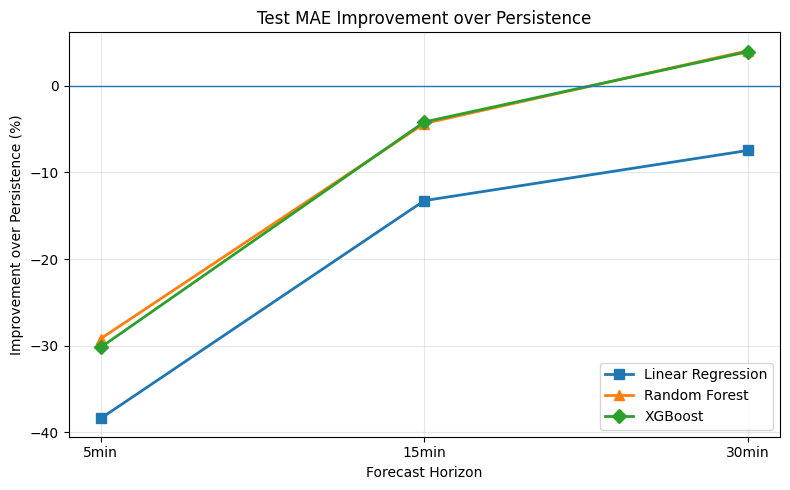

In [6]:
# Figure 3. Percent improvement over persistence
# ------------------------------------------------------------------
persistence_rows = overall_results.loc[
    overall_results["model"] == "Persistence",
    ["horizon", "test_mae", "test_rmse"]
].copy()

persistence_rows = persistence_rows.rename(
    columns={
        "test_mae": "persistence_test_mae",
        "test_rmse": "persistence_test_rmse",
    }
)

improvement_results = overall_results.merge(persistence_rows, on="horizon", how="left")

improvement_results["test_mae_improvement_pct"] = (
    (improvement_results["persistence_test_mae"] - improvement_results["test_mae"])
    / improvement_results["persistence_test_mae"]
) * 100.0

improvement_plot_data = (
    improvement_results[improvement_results["model"] != "Persistence"]
    .pivot(index="horizon", columns="model", values="test_mae_improvement_pct")
    .reindex(horizon_order)
)

plt.figure(figsize=(8, 5))

for current_model in ["Linear Regression", "Random Forest", "XGBoost"]:
    if current_model in improvement_plot_data.columns:
        plt.plot(
            improvement_plot_data.index.astype(str),
            improvement_plot_data[current_model],
            marker=marker_map[current_model],
            linewidth=2,
            markersize=7,
            label=current_model
        )

plt.axhline(0, linewidth=1)
plt.xlabel("Forecast Horizon")
plt.ylabel("Improvement over Persistence (%)")
plt.title("Test MAE Improvement over Persistence")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(
    os.path.join(figures_directory, "figure_04_test_mae_improvement_over_persistence.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Figure. Per-TMC MAE distribution by horizon

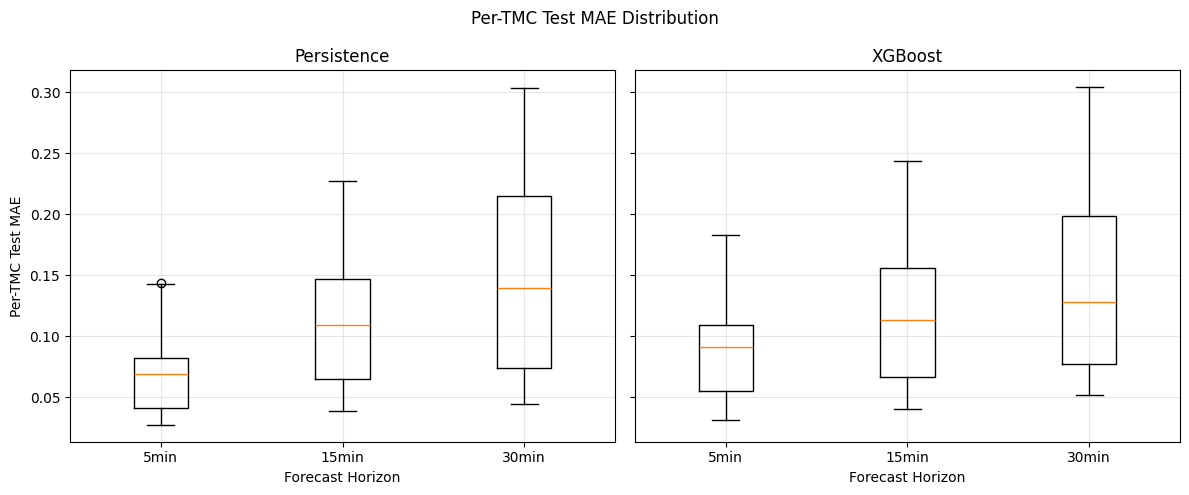

In [7]:
# Figure 5. Per-TMC MAE distribution on TEST split
# =========================================================
per_tmc_test = per_tmc_results[per_tmc_results["split"].str.lower() == "test"].copy()

models_for_distribution_plot = ["Persistence", "XGBoost"]

fig, axes = plt.subplots(1, len(models_for_distribution_plot), figsize=(12, 5), sharey=True)

if len(models_for_distribution_plot) == 1:
    axes = [axes]

for axis, current_model in zip(axes, models_for_distribution_plot):
    model_subset = per_tmc_test[per_tmc_test["model"] == current_model]

    boxplot_values = []
    for current_horizon in horizon_order:
        values = model_subset.loc[
            model_subset["horizon"] == current_horizon, "mae"
        ].dropna().values
        boxplot_values.append(values)

    axis.boxplot(boxplot_values, tick_labels=horizon_order)
    axis.set_title(current_model)
    axis.set_xlabel("Forecast Horizon")
    axis.grid(True, alpha=0.3)

axes[0].set_ylabel("Per-TMC Test MAE")
fig.suptitle("Per-TMC Test MAE Distribution")
plt.tight_layout()
plt.savefig(
    os.path.join(figures_directory, "figure_05_per_tmc_test_mae_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Figure. Per-year MAE by horizon and model

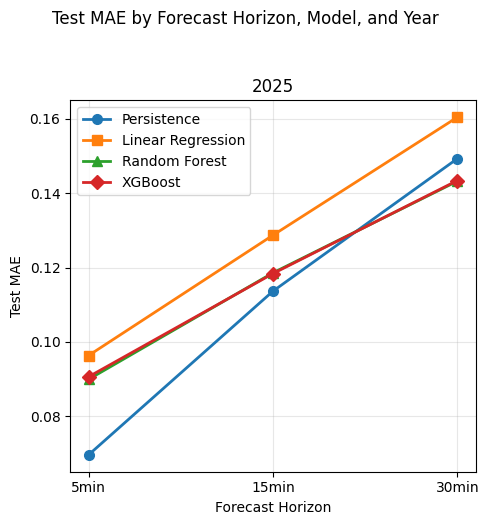

In [8]:
# Figure 6. Per-year TEST MAE panel
# =========================================================
per_year_test = per_year_results[per_year_results["split"].str.lower() == "test"].copy()
years_to_plot = sorted(per_year_test["year"].dropna().unique())

n_years = len(years_to_plot)
fig, axes = plt.subplots(1, n_years, figsize=(5 * n_years, 5), sharey=True)

if n_years == 1:
    axes = [axes]

for axis, current_year in zip(axes, years_to_plot):
    year_subset = per_year_test[per_year_test["year"] == current_year].copy()

    year_plot_data = (
        year_subset
        .pivot(index="horizon", columns="model", values="mae")
        .reindex(horizon_order)
    )

    for current_model in model_order:
        if current_model in year_plot_data.columns:
            axis.plot(
                year_plot_data.index.astype(str),
                year_plot_data[current_model],
                marker=marker_map[current_model],
                linewidth=2,
                markersize=7,
                label=current_model
            )

    axis.set_title(str(int(current_year)))
    axis.set_xlabel("Forecast Horizon")
    axis.grid(True, alpha=0.3)

axes[0].set_ylabel("Test MAE")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(loc="upper left", frameon=True)
fig.suptitle("Test MAE by Forecast Horizon, Model, and Year", y=1.04)
plt.tight_layout()
plt.savefig(
    os.path.join(figures_directory, "figure_06_per_year_test_mae_panel.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Optional. Heatmap table for paper or PPT

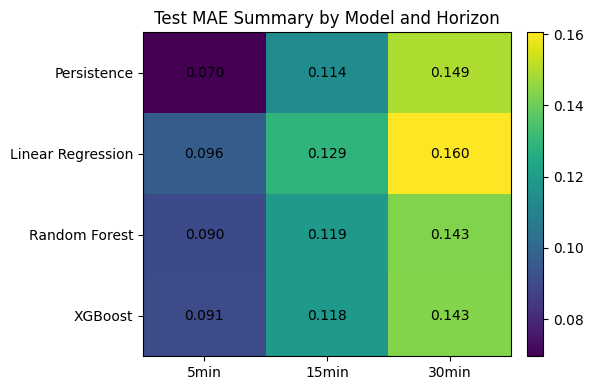

In [9]:
# Figure 7. Test MAE heatmap
# =========================================================
heatmap_data = (
    overall_results
    .pivot(index="model", columns="horizon", values="test_mae")
    .reindex(model_order)
)

fig, ax = plt.subplots(figsize=(6, 4))
image = ax.imshow(heatmap_data.values, aspect="auto")

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for row_index in range(heatmap_data.shape[0]):
    for col_index in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[row_index, col_index]
        if pd.notna(value):
            ax.text(col_index, row_index, f"{value:.3f}", ha="center", va="center")

ax.set_title("Test MAE Summary by Model and Horizon")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(
    os.path.join(figures_directory, "figure_07_test_mae_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

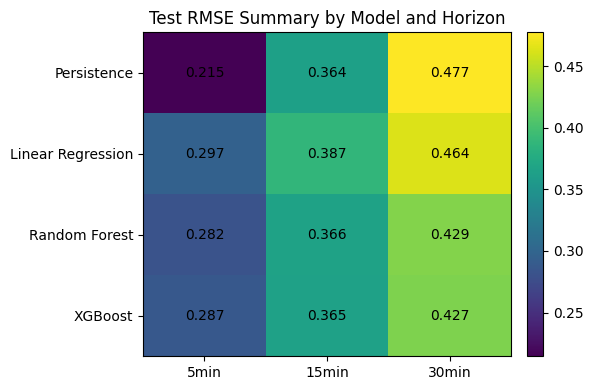

In [10]:
# Figure 8. Test RMSE heatmap
# =========================================================
heatmap_data_rmse = (
    overall_results
    .pivot(index="model", columns="horizon", values="test_rmse")
    .reindex(model_order)
)

fig, ax = plt.subplots(figsize=(6, 4))
image = ax.imshow(heatmap_data_rmse.values, aspect="auto")

ax.set_xticks(range(len(heatmap_data_rmse.columns)))
ax.set_xticklabels(heatmap_data_rmse.columns)
ax.set_yticks(range(len(heatmap_data_rmse.index)))
ax.set_yticklabels(heatmap_data_rmse.index)

for row_index in range(heatmap_data_rmse.shape[0]):
    for col_index in range(heatmap_data_rmse.shape[1]):
        value = heatmap_data_rmse.iloc[row_index, col_index]
        if pd.notna(value):
            ax.text(col_index, row_index, f"{value:.3f}", ha="center", va="center")

ax.set_title("Test RMSE Summary by Model and Horizon")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(
    os.path.join(figures_directory, "figure_08_test_rmse_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Statistical Significance Test

In [11]:
from scipy.stats import wilcoxon
import pandas as pd

# keep only test split
significance_input = per_tmc_results[per_tmc_results["split"] == "test"].copy()

significance_rows = []

for current_horizon in ["5min", "15min", "30min"]:
    horizon_data = significance_input[significance_input["horizon"] == current_horizon].copy()

    persistence_data = (
        horizon_data[horizon_data["model"] == "Persistence"][["tmc", "direction", "mae"]]
        .rename(columns={"mae": "mae_persistence"})
    )

    for current_model in ["Linear Regression", "Random Forest", "XGBoost"]:
        model_data = (
            horizon_data[horizon_data["model"] == current_model][["tmc", "direction", "mae"]]
            .rename(columns={"mae": "mae_model"})
        )

        paired_data = persistence_data.merge(model_data, on=["tmc", "direction"], how="inner")
        paired_data["mae_difference"] = paired_data["mae_persistence"] - paired_data["mae_model"]

        test_statistic, p_value = wilcoxon(
            paired_data["mae_persistence"],
            paired_data["mae_model"],
            zero_method="wilcox",
            alternative="two-sided"
        )

        significance_rows.append({
            "horizon": current_horizon,
            "model": current_model,
            "number_of_tmcs": len(paired_data),
            "mean_persistence_mae": paired_data["mae_persistence"].mean(),
            "mean_model_mae": paired_data["mae_model"].mean(),
            "mean_improvement": paired_data["mae_difference"].mean(),
            "median_improvement": paired_data["mae_difference"].median(),
            "tmcs_where_model_better": (paired_data["mae_difference"] > 0).sum(),
            "tmcs_where_persistence_better": (paired_data["mae_difference"] < 0).sum(),
            "wilcoxon_statistic": test_statistic,
            "p_value": p_value
        })

significance_results = pd.DataFrame(significance_rows)
significance_results

,horizon,model,number_of_tmcs,mean_persistence_mae,mean_model_mae,mean_improvement,median_improvement,tmcs_where_model_better,tmcs_where_persistence_better,wilcoxon_statistic,p_value
0,5min,Linear Regression,41,0.069602,0.096336,-0.026734,-0.022966,0,41,0.0,9.094947e-13
1,5min,Random Forest,41,0.069602,0.089921,-0.020319,-0.021094,0,41,0.0,9.094947e-13
2,5min,XGBoost,41,0.069602,0.090618,-0.021016,-0.021130,0,41,0.0,9.094947e-13
3,15min,Linear Regression,41,0.113653,0.128716,-0.015063,-0.011205,2,39,7.0,1.728040e-11
4,15min,Random Forest,41,0.113653,0.118589,-0.004936,-0.003478,8,33,89.0,1.619688e-06
5,15min,XGBoost,41,0.113653,0.118385,-0.004732,-0.003772,7,34,99.0,3.827113e-06
6,30min,Linear Regression,41,0.149329,0.160466,-0.011137,-0.008887,10,31,140.0,7.864533e-05
7,30min,Random Forest,41,0.149329,0.143253,0.006076,0.004310,28,13,165.0,3.631249e-04
8,30min,XGBoost,41,0.149329,0.143435,0.005894,0.004214,26,15,206.0,3.003820e-03


In [13]:
significance_table = significance_results.copy()

significance_table["mean_persistence_mae"] = significance_table["mean_persistence_mae"].round(3)
significance_table["mean_model_mae"] = significance_table["mean_model_mae"].round(3)
significance_table["mean_improvement"] = significance_table["mean_improvement"].round(3)
significance_table["median_improvement"] = significance_table["median_improvement"].round(3)
significance_table["p_value"] = significance_table["p_value"].apply(lambda x: f"{x:.2e}")

significance_table = significance_table[
    [
        "horizon",
        "model",
        "number_of_tmcs",
        "mean_persistence_mae",
        "mean_model_mae",
        "mean_improvement",
        "median_improvement",
        "tmcs_where_model_better",
        "tmcs_where_persistence_better",
        "p_value",
    ]
]

significance_table.to_csv(os.path.join(results_directory, "wilcoxon_significance_table.csv"), index=False)